## 1. Configuración y división train/val/test (por taza original)

Se reutiliza el catálogo de tazas rotas ya generado en el notebook de evaluación (172 mugs, un ejemplar de rotura cada una). Se divide por `id_original` — nunca por variante de rotura — en train (70%), validación (15%) y test (15%), con la misma semilla que el resto del proyecto. El subconjunto de test se queda fijado a los `id_original` que caigan ahí; sus roturas ya existentes se reutilizarán sin regenerar, para poder comparar directamente contra la evaluación que ya hicimos antes del fine-tuning.

In [14]:
%pip -q install -U pip

%pip -q install open3d==0.19.0
%pip -q install trimesh scipy pandas matplotlib plotly imageio blenderproc scikit-image

In [15]:
# ============================================================
# 1. CONFIGURACIÓN Y DIVISIÓN TRAIN/VAL/TEST (POR TAZA ORIGINAL)
# ============================================================
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import numpy as np, pandas as pd, random

SEMILLA = 2026
random.seed(SEMILLA); np.random.seed(SEMILLA)

RUTA_BASE = Path("/content/drive/MyDrive/Datos_E2_E3")
RUTA_ORIGINALES = RUTA_BASE / "General/Shapenet_limpias/03797390"
RUTA_ROTAS_EXISTENTES = RUTA_BASE / "General/Shapenet_sintetic_rotas_v2/03797390"  # las 172 ya generadas/evaluadas

RUTA_FT = RUTA_BASE / "General/Shapenet_finetuning_rotas_v2/03797390"
RUTA_FT_PLY = RUTA_FT / "ply"
RUTA_FT_IMAGENES = RUTA_FT / "imagenes"
RUTA_FT_VOXELES = RUTA_FT / "voxeles"
RUTA_FT_DIVISIONES = RUTA_FT / "divisiones"
for r in [RUTA_FT_PLY, RUTA_FT_IMAGENES, RUTA_FT_VOXELES, RUTA_FT_DIVISIONES]:
    r.mkdir(parents=True, exist_ok=True)

FRACCION_TRAIN, FRACCION_VAL, FRACCION_TEST = 0.70, 0.15, 0.15
N_VARIANTES_TRAIN = 4   # roturas nuevas por taza de train
N_VARIANTES_VAL = 2     # roturas nuevas por taza de validación

# ------------------------------------------------------------
# Split reproducible por id_original (igual que en el notebook de entrenamiento)
# ------------------------------------------------------------
ids_originales = sorted(p.stem for p in RUTA_ORIGINALES.glob("*.ply"))
print(f"Tazas originales (categoría mugs): {len(ids_originales)}")

rng = np.random.default_rng(SEMILLA)
ids_barajados = rng.permutation(ids_originales)
n = len(ids_barajados)
n_train = int(round(n * FRACCION_TRAIN))
n_val = int(round(n * FRACCION_VAL))

# Reutilizamos el MISMO split que ya validasteis (sin fugas), no lo regeneramos:
RUTA_FT_DIVISIONES_V1 = RUTA_BASE / "General/Shapenet_finetuning_rotas/03797390/divisiones"
ids_train = sorted(pd.read_csv(RUTA_FT_DIVISIONES_V1 / "train_ids.csv")["id_original"])
ids_val = sorted(pd.read_csv(RUTA_FT_DIVISIONES_V1 / "val_ids.csv")["id_original"])
ids_test = sorted(pd.read_csv(RUTA_FT_DIVISIONES_V1 / "test_ids.csv")["id_original"])
print(f"Train: {len(ids_train)}  |  Val: {len(ids_val)}  |  Test: {len(ids_test)}")

assert set(ids_train) & set(ids_val) == set() and set(ids_train) & set(ids_test) == set() and set(ids_val) & set(ids_test) == set(), "¡Fuga de ids entre splits!"

pd.DataFrame({"id_original": ids_train}).to_csv(RUTA_FT_DIVISIONES / "train_ids.csv", index=False)
pd.DataFrame({"id_original": ids_val}).to_csv(RUTA_FT_DIVISIONES / "val_ids.csv", index=False)
pd.DataFrame({"id_original": ids_test}).to_csv(RUTA_FT_DIVISIONES / "test_ids.csv", index=False)

# ------------------------------------------------------------
# Comprobar que las roturas de TEST ya existen (reutilizables sin regenerar)
# ------------------------------------------------------------
test_ya_generados = [i for i in ids_test if (RUTA_ROTAS_EXISTENTES / "ply" / f"{i}_roto.ply").exists()]
print(f"\nTazas de test con rotura ya generada y evaluada: {len(test_ya_generados)} / {len(ids_test)}")
if len(test_ya_generados) < len(ids_test):
    print("⚠️ Faltan roturas de test — revisar antes de continuar.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tazas originales (categoría mugs): 172
Train: 120  |  Val: 26  |  Test: 26

Tazas de test con rotura ya generada y evaluada: 26 / 26


## 2. Generación de roturas adicionales para train y validación

Se generan varias roturas sintéticas nuevas por taza (4 para train, 2 para validación), reutilizando la misma función de corte aleatorio del notebook de evaluación. Se guardan en `RUTA_FT_PLY`, separado de los datos de test ya existentes, con sufijo `_ft{variante}` para distinguirlas.

In [16]:
# ============================================================
# 2. GENERACIÓN DE ROTURAS SINTÉTICAS PARA TRAIN Y VALIDACIÓN
# ============================================================
import trimesh

from tqdm.auto import tqdm
def generar_rotura_aleatoria(mesh, ratio_min=0.75, ratio_max=0.95, max_intentos=25):
    """Corta la malla con un plano 3D aleatorio, conservando entre ratio_min y ratio_max
    de los vértices — roturas leves: se nota el corte, pero queda la mayor parte de la taza."""
    extents = mesh.extents
    centroid = mesh.centroid
    for _ in range(max_intentos):
        normal = np.random.normal(size=3)
        if np.linalg.norm(normal) == 0:
            continue
        normal /= np.linalg.norm(normal)
        # Plano más cerca del borde del objeto (antes ±0.35, ahora ±0.55) → corta menos volumen
        origin = centroid + np.random.uniform(-0.55, 0.55, size=3) * extents
        broken = mesh.slice_plane(plane_origin=origin, plane_normal=-normal)
        if isinstance(broken, trimesh.Trimesh) and not broken.is_empty:
            ratio = len(broken.vertices) / max(len(mesh.vertices), 1)
            if ratio_min <= ratio <= ratio_max:
                return broken, ratio
    # Fallback: un corte fijo cerca del borde si no se logró el rango en max_intentos
    origin = centroid + 0.55 * extents
    broken = mesh.slice_plane(plane_origin=origin, plane_normal=[-0.3, -0.6, -0.3])
    ratio = len(broken.vertices) / max(len(mesh.vertices), 1) if isinstance(broken, trimesh.Trimesh) else 1.0
    return broken, ratio

def generar_variantes_split(ids_split, n_variantes, nombre_split):
    registros = []
    for id_original in tqdm(ids_split, desc=f"Generando roturas — {nombre_split}"):
        ruta_ply_original = RUTA_ORIGINALES / f"{id_original}.ply"
        mesh = trimesh.load_mesh(ruta_ply_original, process=False)
        if not isinstance(mesh, trimesh.Trimesh):
            mesh = trimesh.util.concatenate(tuple(mesh.geometry.values()))
        for v in range(n_variantes):
            id_roto = f"{id_original}_ft{v+1}"
            out_path = RUTA_FT_PLY / f"{id_roto}.ply"
            broken_mesh, ratio = generar_rotura_aleatoria(mesh)
            broken_mesh.export(out_path)
            registros.append({"id_original": id_original, "id_roto": id_roto,
                               "path_roto": out_path, "split": nombre_split, "ratio_conservado": ratio})
    return pd.DataFrame(registros)

df_rotas_train = generar_variantes_split(ids_train, N_VARIANTES_TRAIN, "train")
df_rotas_val = generar_variantes_split(ids_val, N_VARIANTES_VAL, "val")
df_rotas_test = generar_variantes_split(ids_test, 1, "test")  # NUEVO: 1 rotura leve por taza de test

print(f"Ratio conservado — train: {df_rotas_train['ratio_conservado'].mean():.2%}  |  "
      f"val: {df_rotas_val['ratio_conservado'].mean():.2%}  |  test: {df_rotas_test['ratio_conservado'].mean():.2%}")

df_rotas_finetuning = pd.concat([df_rotas_train, df_rotas_val, df_rotas_test], ignore_index=True)
df_rotas_finetuning.to_csv(RUTA_FT_DIVISIONES / "catalogo_roturas_train_val_test.csv", index=False)

Generando roturas — train:   0%|          | 0/120 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/trimesh/triangles.py:550: RuntimeWarning: divide by zero encountered in divide
  inverse_denominator = 1.0 / (dot00 * dot11 - dot01 * dot01)
/usr/local/lib/python3.12/dist-packages/trimesh/triangles.py:553: RuntimeWarning: invalid value encountered in multiply
  barycentric[:, 2] = (dot00 * dot12 - dot01 * dot02) * inverse_denominator
/usr/local/lib/python3.12/dist-packages/trimesh/triangles.py:554: RuntimeWarning: invalid value encountered in multiply
  barycentric[:, 1] = (dot11 * dot02 - dot01 * dot12) * inverse_denominator
/usr/local/lib/python3.12/dist-packages/trimesh/triangles.py:555: RuntimeWarning: invalid value encountered in subtract
  barycentric[:, 0] = 1 - barycentric[:, 1] - barycentric[:, 2]


Generando roturas — val:   0%|          | 0/26 [00:00<?, ?it/s]

Generando roturas — test:   0%|          | 0/26 [00:00<?, ?it/s]

Ratio conservado — train: 85.91%  |  val: 84.84%  |  test: 84.58%


## 3. Renderizado de las 5 vistas (train + validación)

Se renderizan las 532 roturas nuevas con el mismo script de BlenderProc y la misma configuración de cámaras (5 vistas) que en el notebook de evaluación. La salida se guarda en `RUTA_FT_IMAGENES/<id_roto>/rendering/XX.png`, replicando la estructura de carpetas de `RUTA_IMAGENES` para poder reutilizar el `Dataset` de Pix2Vox++ sin modificarlo. Es reanudable: si el proceso se corta a mitad, al relanzar la celda se saltan las tazas ya renderizadas.

In [17]:
# # ============================================================
# # 3. RENDERIZADO DE LAS 5 VISTAS — TRAIN + VALIDACIÓN
# # ============================================================
# import json, os, subprocess
# from textwrap import dedent

# VISTAS_5_CONFIG = [
#     {'view_id': 0,  'filename': '00.png', 'azimuth_deg': 0.0,   'elevation_deg': 20.0},
#     {'view_id': 5,  'filename': '05.png', 'azimuth_deg': 225.0, 'elevation_deg': 20.0},
#     {'view_id': 10, 'filename': '10.png', 'azimuth_deg': 90.0,  'elevation_deg': 40.0},
#     {'view_id': 14, 'filename': '14.png', 'azimuth_deg': 270.0, 'elevation_deg': 40.0},
#     {'view_id': 19, 'filename': '19.png', 'azimuth_deg': 270.0, 'elevation_deg': 60.0},
# ]
# ARCHIVOS_ESPERADOS = [v['filename'] for v in VISTAS_5_CONFIG]

# RUTA_VISTAS_JSON = RUTA_FT / "camera_views_5.json"
# with open(RUTA_VISTAS_JSON, "w", encoding="utf-8") as f:
#     json.dump(VISTAS_5_CONFIG, f, indent=4)

# SCRIPT_RENDER_PATH = Path("/content/render_5v_worker_ft.py")
# SCRIPT_RENDER_CODE = dedent(r"""
# import blenderproc as bproc
# import argparse, json
# from pathlib import Path
# import imageio.v3 as iio
# import numpy as np

# parser = argparse.ArgumentParser()
# parser.add_argument('--ply', required=True)
# parser.add_argument('--views-json', required=True)
# parser.add_argument('--output-dir', required=True)
# parser.add_argument('--width', type=int, default=224)
# parser.add_argument('--height', type=int, default=224)
# parser.add_argument('--focal-length', type=float, default=50.0)
# parser.add_argument('--radius', type=float, default=2.2)
# args = parser.parse_args()

# out_dir = Path(args.output_dir)
# out_dir.mkdir(parents=True, exist_ok=True)

# with open(args.views_json, 'r', encoding='utf-8') as f:
#     vistas = json.load(f)

# bproc.init()
# objects = bproc.loader.load_obj(args.ply)
# if len(objects) == 0:
#     raise RuntimeError("No se pudo cargar el archivo PLY.")
# obj = objects[0]

# for poly in obj.get_mesh().polygons:
#     poly.use_smooth = True

# mat = bproc.material.create("mat_neutro")
# mat.set_principled_shader_value("Base Color", [0.7, 0.7, 0.7, 1.0])
# mat.set_principled_shader_value("Roughness", 0.4)
# obj.replace_materials(mat)

# bproc.camera.set_intrinsics_from_blender_params(
#     lens=args.focal_length, lens_unit="MILLIMETERS",
#     image_width=args.width, image_height=args.height
# )

# bbox_center = obj.get_bound_box().mean(axis=0)

# for v in vistas:
#     az = np.deg2rad(float(v['azimuth_deg']))
#     el = np.deg2rad(float(v['elevation_deg']))
#     cam_pos = bbox_center + np.array([
#         args.radius * np.cos(el) * np.cos(az),
#         args.radius * np.sin(el),
#         args.radius * np.cos(el) * np.sin(az)
#     ])
#     fwd = bbox_center - cam_pos
#     fwd /= np.linalg.norm(fwd)
#     up_world = np.array([0., 1., 0.])
#     right = np.cross(up_world, fwd)
#     if np.linalg.norm(right) < 1e-5:
#         right = np.array([1., 0., 0.])
#     else:
#         right /= np.linalg.norm(right)
#     up = np.cross(fwd, right)
#     up /= np.linalg.norm(up)
#     rot_mat = np.column_stack((right, up, -fwd))
#     T = bproc.math.build_transformation_mat(cam_pos, rot_mat)
#     bproc.camera.add_camera_pose(T)

# for i, (p_pos, p_energy) in enumerate([
#     ([2.5, -2.5, 3.5], 250), ([-2.0, 1.5, 2.5], 140), ([0.5, 2.5, 3.0], 100)
# ]):
#     light = bproc.types.Light(light_type="POINT", name=f"light_{i}")
#     light.set_location(p_pos)
#     light.set_energy(p_energy)

# bproc.renderer.set_output_format(file_format="PNG", color_depth=8, enable_transparency=True)
# bproc.renderer.set_max_amount_of_samples(32)
# data = bproc.renderer.render(keys_with_alpha_channel={'colors'})

# for v, img in zip(vistas, data['colors']):
#     iio.imwrite(out_dir / v['filename'], img)
# """)
# SCRIPT_RENDER_PATH.write_text(SCRIPT_RENDER_CODE, encoding="utf-8")

# # ------------------------------------------------------------
# # Renderizado (reanudable)
# # ------------------------------------------------------------
# total = len(df_rotas_finetuning)
# procesados = omitidos = errores = 0

# with tqdm(df_rotas_finetuning.itertuples(), total=total, desc="Renderizando train+val", unit="taza") as barra:
#     for fila in barra:
#         out_render_dir = RUTA_FT_IMAGENES / fila.id_roto / "rendering"
#         if out_render_dir.exists():
#             existentes = [f.name for f in out_render_dir.glob("*.png")]
#             if all(f in existentes for f in ARCHIVOS_ESPERADOS):
#                 omitidos += 1
#                 barra.set_postfix(procesados=procesados, omitidas=omitidos, errores=errores)
#                 continue

#         out_render_dir.mkdir(parents=True, exist_ok=True)
#         cmd = ["blenderproc", "run", str(SCRIPT_RENDER_PATH),
#                "--ply", str(fila.path_roto), "--views-json", str(RUTA_VISTAS_JSON),
#                "--output-dir", str(out_render_dir)]
#         env = os.environ.copy(); env["MPLBACKEND"] = "Agg"
#         res = subprocess.run(cmd, capture_output=True, text=True, env=env)

#         if res.returncode != 0:
#             errores += 1
#             print(f"\n❌ Error renderizando {fila.id_roto}:"); print(res.stderr[-500:])
#         else:
#             procesados += 1
#         barra.set_postfix(procesados=procesados, omitidas=omitidos, errores=errores)

# print("\n" + "=" * 60); print("RENDERIZADO COMPLETADO"); print("=" * 60)
# print(f"Total: {total}  |  Renderizados: {procesados}  |  Omitidos: {omitidos}  |  Errores: {errores}")

## 4. Ground truth voxel (binvox) para train y validación

Se voxeliza cada rotura de train/val como volumen **relleno** (no solo superficie), usando el `translate`/`scale` del `model.binvox` original de esa misma taza — el mismo criterio ya validado en la evaluación, y consistente con cómo se generó el ground truth del entrenamiento base (BCE sobre volumen relleno, no cáscara). Los `.binvox` se guardan en `RUTA_FT_VOXELES/<id_roto>/model.binvox`, replicando la estructura de `RUTA_VOXELES` para que el `Dataset` de Pix2Vox++ los recoja sin cambios. No depende del renderizado — puede ejecutarse en paralelo.

In [18]:
# # ============================================================
# # 4. GROUND TRUTH VOXEL (BINVOX) — TRAIN Y VALIDACIÓN
# # ============================================================
# import re, trimesh

# RESOLUCION_VOXEL = 32
# RUTA_VOXELES_ORIGINALES = RUTA_BASE / "E2/Datos_E2_voxel/03797390"

# # ------------------------------------------------------------
# # 4.1 Lector/escritor binvox (idéntico al de evaluación, autocontenido aquí)
# # ------------------------------------------------------------
# def leer_cabecera_binvox(ruta_binvox):
#     with open(ruta_binvox, "rb") as f:
#         linea = f.readline().decode("ascii", errors="replace").strip()
#         if not linea.startswith("#binvox"):
#             raise ValueError(f"No es un binvox válido: {ruta_binvox}")
#         dims = translate = scale = None
#         while True:
#             linea = f.readline().decode("ascii", errors="replace").strip()
#             if linea.startswith("data"):
#                 break
#             partes = linea.split()
#             if not partes:
#                 continue
#             if partes[0] == "dim":
#                 dims = tuple(int(v) for v in partes[1:4])
#             elif partes[0] == "translate":
#                 translate = tuple(float(v) for v in partes[1:4])
#             elif partes[0] == "scale":
#                 scale = float(partes[1])
#     if dims is None or translate is None or scale is None:
#         raise ValueError(f"Cabecera binvox incompleta: {ruta_binvox}")
#     return dims, translate, scale

# def escribir_binvox(volumen, ruta, translate=(0.0, 0.0, 0.0), scale=1.0):
#     vol = np.asarray(volumen, dtype=bool)
#     dim = vol.shape[0]
#     flat = np.transpose(vol, (0, 2, 1)).flatten()
#     with open(ruta, "wb") as f:
#         f.write(b"#binvox 1\n")
#         f.write(f"dim {dim} {dim} {dim}\n".encode())
#         f.write(f"translate {translate[0]} {translate[1]} {translate[2]}\n".encode())
#         f.write(f"scale {scale}\n".encode())
#         f.write(b"data\n")
#         n, i = len(flat), 0
#         while i < n:
#             valor, cuenta = flat[i], 1
#             while i + cuenta < n and flat[i + cuenta] == valor and cuenta < 255:
#                 cuenta += 1
#             f.write(bytes([int(valor), cuenta]))
#             i += cuenta

# def identificador_original_ft(id_roto):
#     """Quita el sufijo '_ftN' para recuperar el ID de ShapeNet."""
#     return re.sub(r"_ft\d+$", "", id_roto)

# def ply_roto_a_voxel_32_relleno(ruta_ply, translate, scale, resolucion=RESOLUCION_VOXEL):
#     """Voxeliza el VOLUMEN RELLENO del .ply roto (mismo criterio que el GT de entrenamiento base)."""
#     mesh = trimesh.load(ruta_ply, force="mesh", process=False)
#     if not isinstance(mesh, trimesh.Trimesh) or mesh.is_empty:
#         raise ValueError(f"Malla vacía o inválida: {ruta_ply}")
#     pitch_local = scale / float(resolucion)
#     vg = mesh.voxelized(pitch=pitch_local, method="subdivide")
#     if mesh.is_watertight:
#         vg = vg.fill()
#     translate = np.asarray(translate, dtype=np.float64)
#     puntos = (np.asarray(vg.points, dtype=np.float64) - translate) / scale
#     volumen = np.zeros((resolucion,) * 3, dtype=bool)
#     puntos = np.clip(puntos, 0.0, 1.0 - 1e-10)
#     idx = np.floor(puntos * resolucion).astype(np.int32)
#     validos = np.all((idx >= 0) & (idx < resolucion), axis=1)
#     idx = idx[validos]
#     volumen[idx[:, 0], idx[:, 1], idx[:, 2]] = True
#     return volumen

# # ------------------------------------------------------------
# # 4.2 Generar el binvox de cada rotura de train/val (reanudable)
# # ------------------------------------------------------------
# resultados_gt_ft = []
# primer_error_gt = False

# for fila in tqdm(df_rotas_finetuning.itertuples(), total=len(df_rotas_finetuning), desc="GT binvox train+val"):
#     ruta_out = RUTA_FT_VOXELES / fila.id_roto / "model.binvox"
#     if ruta_out.exists():
#         resultados_gt_ft.append({"id_roto": fila.id_roto, "estado": "omitido"})
#         continue
#     ruta_out.parent.mkdir(parents=True, exist_ok=True)
#     try:
#         ruta_bv_original = RUTA_VOXELES_ORIGINALES / fila.id_original / "model.binvox"
#         _, translate, scale = leer_cabecera_binvox(ruta_bv_original)
#         volumen = ply_roto_a_voxel_32_relleno(fila.path_roto, translate, scale)
#         if volumen.sum() == 0:
#             resultados_gt_ft.append({"id_roto": fila.id_roto, "estado": "volumen_vacio"})
#             continue
#         escribir_binvox(volumen, ruta_out, translate=translate, scale=scale)
#         resultados_gt_ft.append({"id_roto": fila.id_roto, "estado": "ok", "voxeles_ocupados": int(volumen.sum())})
#     except Exception as exc:
#         if not primer_error_gt:
#             import traceback; print(f"\n--- Primer error ({fila.id_roto}) ---"); traceback.print_exc()
#             primer_error_gt = True
#         resultados_gt_ft.append({"id_roto": fila.id_roto, "estado": "error", "error": f"{type(exc).__name__}: {exc}"})

# df_gt_ft = pd.DataFrame(resultados_gt_ft)
# df_gt_ft.to_csv(RUTA_FT_DIVISIONES / "gt_binvox_train_val_estado.csv", index=False)
# print(df_gt_ft["estado"].value_counts())
# if "voxeles_ocupados" in df_gt_ft.columns:
#     print("\nVóxeles ocupados por objeto (volumen relleno):")
#     print(df_gt_ft["voxeles_ocupados"].describe())

## 5. Catálogo final de fine-tuning (train + val + test)

Se construye un único catálogo con todas las tazas rotas de fine-tuning: las de train y validación recién generadas, más las 26 de test que ya existían (reutilizadas sin cambios). Cada fila apunta a sus 5 vistas renderizadas y a su `model.binvox`, con la columna `split` para filtrar después en el `Dataset`.

In [19]:
# ============================================================
# 5. CATÁLOGO FINAL DE FINE-TUNING (TRAIN + VAL + TEST)
# ============================================================
CATEGORIA = "03797390"
ARCHIVOS_ESPERADOS = ["00.png", "05.png", "10.png", "14.png", "19.png"]

def construir_fila_catalogo(id_roto, id_original, split, dir_imagenes, dir_voxeles):
    dir_render = dir_imagenes / id_roto / "rendering"
    ruta_binvox = dir_voxeles / id_roto / "model.binvox"
    vistas_ok = all((dir_render / f).exists() for f in ARCHIVOS_ESPERADOS)
    return {
        "id_roto": id_roto, "id_original": id_original, "categoria": CATEGORIA, "split": split,
        "dir_rendering": dir_render, "ruta_binvox": ruta_binvox,
        "vistas_completas": vistas_ok, "binvox_existe": ruta_binvox.exists(),
    }

# Train + validación (recién generadas)
filas_train_val = [
    construir_fila_catalogo(fila.id_roto, fila.id_original, fila.split, RUTA_FT_IMAGENES, RUTA_FT_VOXELES)
    for fila in df_rotas_finetuning.itertuples()
]

# Test (reutilizando lo ya generado en ACM Evaluación, sin tocar)
def construir_fila_catalogo_test(id_roto, id_original, dir_imagenes, ruta_binvox):
    dir_render = dir_imagenes / id_roto / "rendering"
    vistas_ok = all((dir_render / f).exists() for f in ARCHIVOS_ESPERADOS)
    return {
        "id_roto": id_roto, "id_original": id_original, "categoria": CATEGORIA, "split": "test",
        "dir_rendering": dir_render, "ruta_binvox": ruta_binvox,
        "vistas_completas": vistas_ok, "binvox_existe": ruta_binvox.exists(),
    }

filas_test = [
    construir_fila_catalogo_test(
        f"{id_original}_roto", id_original,
        RUTA_ROTAS_EXISTENTES / "renders_5v",
        RUTA_ROTAS_EXISTENTES / "binvox" / "gt" / f"{id_original}_roto.binvox",
    )
    for id_original in ids_test
]

# ============================================================
# 5. CATÁLOGO FINAL DE FINE-TUNING (TRAIN + VAL + TEST) — v2
# ============================================================
filas_catalogo = [
    construir_fila_catalogo(fila.id_roto, fila.id_original, fila.split, RUTA_FT_IMAGENES, RUTA_FT_VOXELES)
    for fila in df_rotas_finetuning.itertuples()
]
df_catalogo_ft = pd.DataFrame(filas_catalogo)

print(df_catalogo_ft.groupby("split").size())
print("\nCon vistas completas y binvox:")
print(df_catalogo_ft.groupby("split")[["vistas_completas", "binvox_existe"]].sum())

incompletos = df_catalogo_ft[~(df_catalogo_ft["vistas_completas"] & df_catalogo_ft["binvox_existe"])]
if len(incompletos):
    print(f"\n⚠️ {len(incompletos)} filas incompletas:")
    display(incompletos[["id_roto", "split", "vistas_completas", "binvox_existe"]].head(10))

df_catalogo_ft.to_csv(RUTA_FT_DIVISIONES / "catalogo_finetuning_completo.csv", index=False)

split
test      26
train    480
val       52
dtype: int64

Con vistas completas y binvox:
       vistas_completas  binvox_existe
split                                 
test                 26             26
train               480            480
val                  52             52


## 6. Dataset y DataLoader de fine-tuning

Se reutiliza `DatasetPix2Vox` del notebook de entrenamiento, con dos adaptaciones: (1) el cargador de imagen exacto con orden de canales BGR y fondo gris `240/255`, para ser 100% coherente con cómo se entrenó el checkpoint base; (2) una subclase que fija las 5 vistas también en modo `train`, ya que solo se renderizaron esas 5 (no las 20 completas), compensando la falta de augmentación por vista con la variedad de roturas ya generadas.

In [20]:
# ============================================================
# 6. DATASET Y DATALOADER DE FINE-TUNING
# ============================================================
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import random

TAMANO_IMAGEN = 224
RESOLUCION_VOXEL = 32
MEDIA_IMAGEN = np.array([0.5, 0.5, 0.5], dtype=np.float32)
DESVIACION_IMAGEN = np.array([0.5, 0.5, 0.5], dtype=np.float32)
COLOR_FONDO_EVAL = (240/255, 240/255, 240/255)
INDICES_VISTAS_FIJAS_FT = [0, 5, 10, 14, 19]  # las únicas 5 que renderizamos

# ------------------------------------------------------------
# 6.1 Cargador de imagen — idéntico al del notebook de entrenamiento (BGR + fondo gris)
# ------------------------------------------------------------
def cargar_imagen_pix2vox(ruta_imagen, color_fondo):
    ruta_imagen = Path(ruta_imagen)
    if not ruta_imagen.exists():
        raise FileNotFoundError(f"No se ha encontrado la imagen:\n{ruta_imagen}")
    with Image.open(ruta_imagen) as imagen:
        imagen = imagen.convert("RGBA").resize((TAMANO_IMAGEN, TAMANO_IMAGEN), resample=Image.Resampling.BILINEAR)
        imagen_rgba = np.asarray(imagen, dtype=np.float32) / 255.0
    rgb = imagen_rgba[:, :, :3]
    alpha = imagen_rgba[:, :, 3:4]
    fondo = np.asarray(color_fondo, dtype=np.float32).reshape(1, 1, 3)
    rgb = rgb * alpha + fondo * (1.0 - alpha)
    bgr = rgb[:, :, ::-1].copy()  # el modelo se entrenó con OpenCV → BGR
    bgr = (bgr - MEDIA_IMAGEN) / DESVIACION_IMAGEN
    return torch.from_numpy(np.transpose(bgr, (2, 0, 1)).copy()).float()

# ------------------------------------------------------------
# 6.2 leer_binvox — idéntico al vuestro (tolerante a cabecera variable)
# ------------------------------------------------------------
def leer_binvox(ruta_binvox):
    ruta_binvox = Path(ruta_binvox)
    with ruta_binvox.open("rb") as archivo:
        primera_linea = archivo.readline().decode("ascii", errors="replace").strip()
        if not primera_linea.startswith("#binvox"):
            raise ValueError(f"Cabecera BINVOX inválida: {ruta_binvox}")
        dimensiones = traslacion = escala = None
        while True:
            linea = archivo.readline().decode("ascii", errors="replace").strip()
            if not linea:
                continue
            partes = linea.split()
            campo = partes[0].lower()
            if campo == "dim":
                dimensiones = tuple(int(v) for v in partes[1:4])
            elif campo == "translate":
                traslacion = tuple(float(v) for v in partes[1:4])
            elif campo == "scale":
                escala = float(partes[1])
            elif campo == "data":
                break
        datos = np.frombuffer(archivo.read(), dtype=np.uint8)
    valores, repeticiones = datos[0::2], datos[1::2].astype(np.int64)
    volumen = np.repeat(valores, repeticiones).reshape(dimensiones)
    volumen = np.ascontiguousarray(np.transpose(volumen, (0, 2, 1)), dtype=np.float32)
    return volumen, {"dim": dimensiones, "translate": traslacion, "scale": escala}

# ------------------------------------------------------------
# 6.3 Dataset — subclase con vistas fijas también en train
# ------------------------------------------------------------
class DatasetPix2VoxRoturas(Dataset):
    """Igual que DatasetPix2Vox del notebook de entrenamiento, pero usa
    siempre las 5 vistas fijas [0,5,10,14,19] (train incluido), porque
    solo se renderizaron esas 5 para las roturas sintéticas."""

    def __init__(self, dataframe, modo, fondo_aleatorio_entrenamiento=True, cachear_voxeles=True):
        if modo not in {"train", "validacion", "test"}:
            raise ValueError("modo debe ser 'train', 'validacion' o 'test'.")
        if dataframe.empty:
            raise ValueError("El DataFrame proporcionado está vacío.")
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.modo = modo
        self.fondo_aleatorio_entrenamiento = fondo_aleatorio_entrenamiento
        self.cachear_voxeles = cachear_voxeles
        self._cache_voxeles = {}

    def __len__(self):
        return len(self.dataframe)

    def _generar_color_fondo(self):
        if self.modo == "train" and self.fondo_aleatorio_entrenamiento:
            return np.random.randint(low=225, high=256, size=3).astype(np.float32) / 255.0
        return np.full(shape=3, fill_value=240.0 / 255.0, dtype=np.float32)

    def _cargar_voxel(self, ruta_binvox):
        clave = str(ruta_binvox)
        if self.cachear_voxeles and clave in self._cache_voxeles:
            # Recupera en uint8 y convierte a float32 al vuelo
            return self._cache_voxeles[clave].to(torch.float32)

        volumen, _ = leer_binvox(ruta_binvox)
        # Guarda en la caché comprimido como uint8
        tensor_voxel = torch.from_numpy(volumen).to(torch.uint8)

        if self.cachear_voxeles:
            self._cache_voxeles[clave] = tensor_voxel

        return tensor_voxel.to(torch.float32)

    def __getitem__(self, indice):
        fila = self.dataframe.iloc[indice]
        color_fondo = self._generar_color_fondo()
        imagenes = [cargar_imagen_pix2vox(fila[f"vista_{idx:02d}"], color_fondo) for idx in INDICES_VISTAS_FIJAS_FT]
        tensor_imagenes = torch.stack(imagenes, dim=0)
        tensor_voxel = self._cargar_voxel(fila["ruta_binvox"])
        return {
            "imagenes": tensor_imagenes, "voxel": tensor_voxel,
            "categoria": str(fila["categoria"]), "identificador": str(fila["identificador"]),
            "indices_vistas": torch.tensor(INDICES_VISTAS_FIJAS_FT, dtype=torch.long),
        }

# ------------------------------------------------------------
# 6.4 Completar el catálogo con columnas vista_00..vista_19 y "identificador"
# ------------------------------------------------------------
for idx in INDICES_VISTAS_FIJAS_FT:
    nombre_archivo = f"{idx:02d}.png"
    df_catalogo_ft[f"vista_{idx:02d}"] = df_catalogo_ft["dir_rendering"].apply(lambda d: d / nombre_archivo)
df_catalogo_ft["identificador"] = df_catalogo_ft["id_roto"]

df_catalogo_ft_ok = df_catalogo_ft[df_catalogo_ft["vistas_completas"] & df_catalogo_ft["binvox_existe"]].copy()
print(f"Catálogo completo utilizable: {len(df_catalogo_ft_ok)} / {len(df_catalogo_ft)}")
print(df_catalogo_ft_ok.groupby("split").size())

df_train_ft = df_catalogo_ft_ok[df_catalogo_ft_ok["split"] == "train"].reset_index(drop=True)
df_val_ft = df_catalogo_ft_ok[df_catalogo_ft_ok["split"] == "val"].reset_index(drop=True)
df_test_ft = df_catalogo_ft_ok[df_catalogo_ft_ok["split"] == "test"].reset_index(drop=True)

# ------------------------------------------------------------
# 6.5 DataLoaders (mismos parámetros que crear_dataloaders_pix2vox)
# ------------------------------------------------------------
TAMANO_LOTE_FISICO_FT = 2
NUM_WORKERS_DATALOADER_FT = 0

dataset_train_ft = DatasetPix2VoxRoturas(df_train_ft, modo="train", fondo_aleatorio_entrenamiento=True, cachear_voxeles=True)
dataset_val_ft = DatasetPix2VoxRoturas(df_val_ft, modo="validacion", fondo_aleatorio_entrenamiento=False, cachear_voxeles=True)
dataset_test_ft = DatasetPix2VoxRoturas(df_test_ft, modo="test", fondo_aleatorio_entrenamiento=False, cachear_voxeles=True)

generador_train_ft = torch.Generator(); generador_train_ft.manual_seed(SEMILLA)

loader_train_ft = DataLoader(dataset_train_ft, batch_size=TAMANO_LOTE_FISICO_FT, shuffle=True,
                              num_workers=NUM_WORKERS_DATALOADER_FT, drop_last=False, generator=generador_train_ft)
loader_val_ft = DataLoader(dataset_val_ft, batch_size=TAMANO_LOTE_FISICO_FT, shuffle=False,
                            num_workers=NUM_WORKERS_DATALOADER_FT, drop_last=False)
loader_test_ft = DataLoader(dataset_test_ft, batch_size=TAMANO_LOTE_FISICO_FT, shuffle=False,
                             num_workers=NUM_WORKERS_DATALOADER_FT, drop_last=False)

print(f"\nBatches — train: {len(loader_train_ft)}  val: {len(loader_val_ft)}  test: {len(loader_test_ft)}")

# Comprobación rápida: un batch de train sin errores
batch_prueba = next(iter(loader_train_ft))
print("Shapes batch de prueba:", batch_prueba["imagenes"].shape, batch_prueba["voxel"].shape)

Catálogo completo utilizable: 558 / 558
split
test      26
train    480
val       52
dtype: int64

Batches — train: 240  val: 26  test: 13
Shapes batch de prueba: torch.Size([2, 5, 3, 224, 224]) torch.Size([2, 32, 32, 32])


## 7. Carga del checkpoint exp13 y configuración del fine-tuning

Se carga `exp13_7categorias_5v_finetuning_mejor.pth` como punto de partida y se configura un único experimento de fine-tuning (`exp_ft_tazas_rotas`), reutilizando los mismos hiperparámetros que ya usasteis: LR distinto por módulo (encoder/decoder/merger/refiner), Adam, `ReduceLROnPlateau` sobre IoU de validación, recorte de gradiente y BatchNorm congelado en modo evaluación durante el entrenamiento.

In [21]:
# ============================================================
# 7. CARGA DEL CHECKPOINT EXP13 Y CONFIGURACIÓN DEL FINE-TUNING
# ============================================================
import sys, torch.nn as nn

RUTA_NOTEBOOKS = Path("/content/drive/MyDrive/Colab Notebooks")
if str(RUTA_NOTEBOOKS) not in sys.path:
    sys.path.append(str(RUTA_NOTEBOOKS))

from modelo_pix2vox import Pix2VoxPlusPlusA, cargar_checkpoint_finetuning, DEVICE

# ------------------------------------------------------------
# 7.1 Cargar el modelo base (exp13)
# ------------------------------------------------------------
RUTA_CHECKPOINT_BASE = RUTA_BASE / "E2/Pix2Vox++/checkpoints/exp13_7categorias_5v_finetuning_mejor.pth"
if not RUTA_CHECKPOINT_BASE.exists():
    raise FileNotFoundError(f"No se encuentra:\n{RUTA_CHECKPOINT_BASE}")

modelo_ft = Pix2VoxPlusPlusA(usar_refiner=True, usar_merger=True, usar_pesos_imagenet=False)
meta_ckpt_base = cargar_checkpoint_finetuning(modelo=modelo_ft, ruta_checkpoint=RUTA_CHECKPOINT_BASE,
                                               dispositivo_carga="cpu", estricto=True)
if meta_ckpt_base["claves_ausentes"] or meta_ckpt_base["claves_inesperadas"]:
    raise RuntimeError("El checkpoint base no coincide con la arquitectura.")

modelo_ft = modelo_ft.to(DEVICE)
print(f"Checkpoint base cargado: exp13 (IoU test original: {meta_ckpt_base['mejor_iou_validacion']:.4f})")
print(f"Dispositivo: {DEVICE}")

# ------------------------------------------------------------
# 7.2 Rutas del nuevo experimento
# ------------------------------------------------------------
NOMBRE_EXP_FT = "exp_ft_tazas_rotas_leves"
RUTA_CHECKPOINTS_FT = RUTA_FT / "checkpoints"
RUTA_HISTORIALES_FT = RUTA_FT / "historiales"
for r in [RUTA_CHECKPOINTS_FT, RUTA_HISTORIALES_FT]:
    r.mkdir(parents=True, exist_ok=True)

RUTA_CHECKPOINT_MEJOR_FT = RUTA_CHECKPOINTS_FT / f"{NOMBRE_EXP_FT}_mejor.pth"
RUTA_CHECKPOINT_ULTIMO_FT = RUTA_CHECKPOINTS_FT / f"{NOMBRE_EXP_FT}_ultimo.pth"
RUTA_HISTORIAL_FT = RUTA_HISTORIALES_FT / f"{NOMBRE_EXP_FT}_historial.csv"

# ------------------------------------------------------------
# 7.3 Hiperparámetros (idénticos a la sección 11 del notebook de entrenamiento)
# ------------------------------------------------------------
NUMERO_EPOCAS_MAXIMO = 19
PACIENCIA_EARLY_STOPPING = 7
PACIENCIA_REDUCCION_LR = 3
FACTOR_REDUCCION_LR = 0.5
TASA_APRENDIZAJE_MINIMA = 1e-7

TASA_APRENDIZAJE_ENCODER = 1e-5
TASA_APRENDIZAJE_DECODER = 1e-4
TASA_APRENDIZAJE_MERGER = 1e-5
TASA_APRENDIZAJE_REFINER = 1e-4

BETAS_ADAM = (0.9, 0.999)
WEIGHT_DECAY = 1e-5
NORMA_MAXIMA_GRADIENTE = 1.0

PESO_PERDIDA_FUSION = 1.0
PESO_PERDIDA_REFINER = 1.0

USAR_PRECISION_MIXTA = False  # igual que en el notebook original

TIPOS_BATCH_NORMALIZATION = (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)

# ------------------------------------------------------------
# 7.4 BatchNorm congelado (estadísticas fijas durante fine-tuning)
# ------------------------------------------------------------
def congelar_estadisticas_batchnorm(modelo, congelar_parametros=False):
    numero_capas = 0
    for modulo in modelo.modules():
        if isinstance(modulo, TIPOS_BATCH_NORMALIZATION):
            numero_capas += 1
            modulo.eval()
            if congelar_parametros:
                if modulo.weight is not None: modulo.weight.requires_grad = False
                if modulo.bias is not None: modulo.bias.requires_grad = False
    return numero_capas

def activar_modo_finetuning(modelo):
    modelo.train()
    return congelar_estadisticas_batchnorm(modelo, congelar_parametros=False)

# ------------------------------------------------------------
# 7.5 Optimizador (LR distinto por módulo) y scheduler
# ------------------------------------------------------------
def crear_optimizador_finetuning(modelo):
    grupos_parametros = [
        {"params": [p for p in modelo.encoder.parameters() if p.requires_grad], "lr": TASA_APRENDIZAJE_ENCODER, "nombre": "encoder"},
        {"params": [p for p in modelo.decoder.parameters() if p.requires_grad], "lr": TASA_APRENDIZAJE_DECODER, "nombre": "decoder"},
        {"params": [p for p in modelo.merger.parameters() if p.requires_grad], "lr": TASA_APRENDIZAJE_MERGER, "nombre": "merger"},
        {"params": [p for p in modelo.refiner.parameters() if p.requires_grad], "lr": TASA_APRENDIZAJE_REFINER, "nombre": "refiner"},
    ]
    for grupo in grupos_parametros:
        if len(grupo["params"]) == 0:
            raise RuntimeError(f"El grupo de parámetros '{grupo['nombre']}' está vacío.")
    return torch.optim.Adam(grupos_parametros, betas=BETAS_ADAM, weight_decay=WEIGHT_DECAY)

def crear_scheduler_finetuning(optimizador):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer=optimizador, mode="max", factor=FACTOR_REDUCCION_LR,
        patience=PACIENCIA_REDUCCION_LR, min_lr=TASA_APRENDIZAJE_MINIMA)

optimizador_ft = crear_optimizador_finetuning(modelo_ft)
scheduler_ft = crear_scheduler_finetuning(optimizador_ft)
escalador_ft = torch.amp.GradScaler("cuda", enabled=USAR_PRECISION_MIXTA)

print("\n" + "=" * 75)
print(f"CONFIGURACIÓN DE FINE-TUNING — {NOMBRE_EXP_FT}")
print("=" * 75)
print(f"Épocas máx.: {NUMERO_EPOCAS_MAXIMO}  |  Paciencia early stopping: {PACIENCIA_EARLY_STOPPING}")
print(f"LR encoder/decoder/merger/refiner: {TASA_APRENDIZAJE_ENCODER}/{TASA_APRENDIZAJE_DECODER}/{TASA_APRENDIZAJE_MERGER}/{TASA_APRENDIZAJE_REFINER}")
print(f"Checkpoint mejor: {RUTA_CHECKPOINT_MEJOR_FT}")
print(f"Train/Val/Test: {len(dataset_train_ft)}/{len(dataset_val_ft)}/{len(dataset_test_ft)}")

Checkpoint base cargado: exp13 (IoU test original: 0.6546)
Dispositivo: cuda

CONFIGURACIÓN DE FINE-TUNING — exp_ft_tazas_rotas_leves
Épocas máx.: 19  |  Paciencia early stopping: 7
LR encoder/decoder/merger/refiner: 1e-05/0.0001/1e-05/0.0001
Checkpoint mejor: /content/drive/MyDrive/Datos_E2_E3/General/Shapenet_finetuning_rotas_v2/03797390/checkpoints/exp_ft_tazas_rotas_leves_mejor.pth
Train/Val/Test: 480/52/26


## 8. Función de una época y evaluación en validación/test

Se reutiliza (adaptada a este dataset) la función de entrenamiento de una época de la sección 12 del notebook de Pix2Vox++: BCE sobre fusión y refiner, precisión mixta opcional, recorte de gradiente, BatchNorm congelado. La evaluación selecciona el umbral óptimo en validación probando varios candidatos (igual que en vuestros experimentos) y con ese umbral fijo calcula IoU/Dice/Precisión/Recall.

In [22]:
# ============================================================
# 8. ENTRENAMIENTO DE UNA ÉPOCA Y EVALUACIÓN
# ============================================================
import time
from tqdm.auto import tqdm

EPSILON_METRICAS = 1e-8
UMBRALES_EVALUACION = (0.15, 0.2, 0.3, 0.4, 0.5)
UMBRAL_MONITORIZACION_TRAIN = 0.3

# ------------------------------------------------------------
# 8.1 Pérdida y métricas (idénticas a la sección 5 del notebook de entrenamiento)
# ------------------------------------------------------------
def normalizar_forma_voxel(tensor):
    if not torch.is_tensor(tensor):
        tensor = torch.as_tensor(tensor, dtype=torch.float32)
    if tensor.ndim == 3:
        tensor = tensor.unsqueeze(0)
    elif tensor.ndim == 5 and tensor.shape[1] == 1:
        tensor = tensor.squeeze(1)
    if tensor.shape[-3:] != (RESOLUCION_VOXEL,) * 3:
        raise ValueError(f"Resolución voxel inesperada: {tuple(tensor.shape)}")
    return tensor.float()

def perdida_reconstruccion_bce(prediccion, ground_truth):
    prediccion = normalizar_forma_voxel(prediccion)
    ground_truth = normalizar_forma_voxel(ground_truth).to(device=prediccion.device, dtype=prediccion.dtype)
    prediccion = prediccion.clamp(min=EPSILON_METRICAS, max=1.0 - EPSILON_METRICAS)
    return F.binary_cross_entropy(prediccion, ground_truth) * 10.0

@torch.no_grad()
def calcular_metricas_voxel(prediccion, ground_truth, umbral=0.3):
    prediccion = normalizar_forma_voxel(prediccion)
    ground_truth = normalizar_forma_voxel(ground_truth).to(device=prediccion.device)
    pred_bin = prediccion >= umbral
    gt_bin = ground_truth >= 0.5
    dims = (1, 2, 3)
    tp = (pred_bin & gt_bin).sum(dim=dims).float()
    fp = (pred_bin & ~gt_bin).sum(dim=dims).float()
    fn = (~pred_bin & gt_bin).sum(dim=dims).float()
    voxeles_pred = tp + fp
    voxeles_gt = tp + fn
    union = tp + fp + fn
    iou = torch.where(union > 0, tp / union.clamp_min(EPSILON_METRICAS), torch.ones_like(union))
    denom_dice = 2.0 * tp + fp + fn
    dice = torch.where(denom_dice > 0, 2.0 * tp / denom_dice.clamp_min(EPSILON_METRICAS), torch.ones_like(denom_dice))
    precision = torch.where(voxeles_pred > 0, tp / voxeles_pred.clamp_min(EPSILON_METRICAS),
                             torch.where(voxeles_gt == 0, torch.ones_like(voxeles_pred), torch.zeros_like(voxeles_pred)))
    recall = torch.where(voxeles_gt > 0, tp / voxeles_gt.clamp_min(EPSILON_METRICAS), torch.ones_like(voxeles_gt))
    return {"iou": iou, "dice": dice, "precision_voxel": precision, "recall_voxel": recall,
            "voxeles_predichos": voxeles_pred, "voxeles_reales": voxeles_gt}

def obtener_tasas_aprendizaje(optimizador):
    return {g.get("nombre", f"grupo_{i}"): float(g["lr"]) for i, g in enumerate(optimizador.param_groups)}

def mover_lote_a_dispositivo(lote, dispositivo=DEVICE):
    imagenes = lote["imagenes"].to(dispositivo, non_blocking=(dispositivo.type == "cuda"))
    ground_truth = lote["voxel"].to(dispositivo, non_blocking=(dispositivo.type == "cuda"))
    return imagenes, ground_truth

# ------------------------------------------------------------
# 8.2 Entrenamiento de una época (fiel a la sección 12 original)
# ------------------------------------------------------------
def entrenar_una_epoca_pix2vox(modelo, dataloader, optimizador, escalador, numero_epoca, max_lotes=None):
    numero_capas_bn = activar_modo_finetuning(modelo)
    optimizador.zero_grad(set_to_none=True)
    numero_lotes_objetivo = len(dataloader) if max_lotes is None else min(len(dataloader), max_lotes)
    if numero_lotes_objetivo == 0:
        raise RuntimeError("El DataLoader no contiene ningún lote.")

    suma_perdida = suma_iou = 0.0
    numero_objetos = numero_lotes = 0
    normas_gradiente = []
    instante_inicio = time.perf_counter()

    barra = tqdm(enumerate(dataloader), total=numero_lotes_objetivo, desc=f"Train época {numero_epoca}", leave=False)
    for indice_lote, lote in barra:
        if indice_lote >= numero_lotes_objetivo:
            break
        imagenes, ground_truth = mover_lote_a_dispositivo(lote)
        tamano_lote = int(imagenes.shape[0])

        tipo_amp = torch.float16 if DEVICE.type == "cuda" else torch.bfloat16
        with torch.amp.autocast(device_type=DEVICE.type, dtype=tipo_amp, enabled=USAR_PRECISION_MIXTA):
            salidas = modelo(imagenes)
            volumen_fusionado = salidas["volumen_fusionado"]
            volumen_final = salidas["volumen_final"]

        perdida_fusion = perdida_reconstruccion_bce(volumen_fusionado.float(), ground_truth.float())
        perdida_refiner = perdida_reconstruccion_bce(volumen_final.float(), ground_truth.float())
        perdida_total = PESO_PERDIDA_FUSION * perdida_fusion + PESO_PERDIDA_REFINER * perdida_refiner
        if not torch.isfinite(perdida_total):
            raise FloatingPointError(f"Pérdida NaN/inf — época {numero_epoca}, lote {indice_lote + 1}.")

        escalador.scale(perdida_total).backward()
        escalador.unscale_(optimizador)
        norma = torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=NORMA_MAXIMA_GRADIENTE,
                                                  norm_type=2.0, error_if_nonfinite=True)
        normas_gradiente.append(float(norma.detach().cpu().item()))
        escalador.step(optimizador)
        escalador.update()
        optimizador.zero_grad(set_to_none=True)

        with torch.no_grad():
            metricas_train = calcular_metricas_voxel(volumen_final.detach(), ground_truth, umbral=UMBRAL_MONITORIZACION_TRAIN)
            iou_lote = float(metricas_train["iou"].mean().item())

        suma_perdida += float(perdida_total.item()) * tamano_lote
        suma_iou += float(metricas_train["iou"].sum().item())
        numero_objetos += tamano_lote
        numero_lotes += 1
        barra.set_postfix({"loss": f"{perdida_total.item():.3f}", "IoU@0.3": f"{iou_lote:.3f}"})

    tiempo_total = time.perf_counter() - instante_inicio
    return {
        "epoca": int(numero_epoca), "numero_objetos": numero_objetos, "numero_lotes": numero_lotes,
        "capas_batchnorm_congeladas": numero_capas_bn,
        "perdida_total_media": suma_perdida / numero_objetos,
        "iou_train_0_3_media": suma_iou / numero_objetos,
        "norma_gradiente_media": float(np.mean(normas_gradiente)) if normas_gradiente else np.nan,
        "tiempo_segundos": tiempo_total,
        "tasas_aprendizaje": obtener_tasas_aprendizaje(optimizador),
    }

# ------------------------------------------------------------
# 8.3 Evaluación (selección de umbral + métricas), versión condensada
# de vuestra evaluar_modelo_pix2vox: igual en fórmulas y umbrales
# candidatos, sin la tabla exhaustiva por objeto (no la necesitamos aquí).
# ------------------------------------------------------------
@torch.no_grad()
def evaluar_modelo_pix2vox(modelo, dataloader, umbrales=UMBRALES_EVALUACION, descripcion="Evaluación"):
    modelo.eval()
    suma_iou = {u: 0.0 for u in umbrales}
    suma_dice = {u: 0.0 for u in umbrales}
    suma_perdida = 0.0
    numero_objetos = 0

    for lote in tqdm(dataloader, desc=descripcion, leave=False):
        imagenes, ground_truth = mover_lote_a_dispositivo(lote)
        salidas = modelo(imagenes)
        prediccion = salidas["volumen_final"]
        tamano_lote = int(imagenes.shape[0])
        perdida = perdida_reconstruccion_bce(prediccion, ground_truth)
        suma_perdida += float(perdida.item()) * tamano_lote
        numero_objetos += tamano_lote
        for u in umbrales:
            m = calcular_metricas_voxel(prediccion, ground_truth, umbral=u)
            suma_iou[u] += float(m["iou"].sum().item())
            suma_dice[u] += float(m["dice"].sum().item())

    tabla_umbrales = pd.DataFrame([
        {"umbral": u, "iou_media": suma_iou[u] / numero_objetos, "dice_media": suma_dice[u] / numero_objetos}
        for u in umbrales
    ])
    mejor_fila = tabla_umbrales.loc[tabla_umbrales["iou_media"].idxmax()]
    return {"perdida_bce_media": suma_perdida / numero_objetos, "numero_objetos": numero_objetos,
            "tabla_umbrales": tabla_umbrales, "mejor_umbral": float(mejor_fila["umbral"]),
            "mejor_iou": float(mejor_fila["iou_media"]), "mejor_dice": float(mejor_fila["dice_media"])}

## 9. Bucle completo de fine-tuning (early stopping + checkpoints)

In [23]:
# ============================================================
# 9. BUCLE COMPLETO DE FINE-TUNING
# ============================================================
import torch.nn.functional as F

def guardar_checkpoint_ft(ruta, modelo, optimizador, scheduler, epoca, mejor_iou):
    torch.save({
        "epoca": epoca,
        "modelo_state_dict": modelo.state_dict(),
        "optimizador_state_dict": optimizador.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "mejor_iou_validacion": mejor_iou,
    }, ruta)

def cargar_checkpoint_ft_si_existe(ruta, modelo, optimizador, scheduler):
    if not ruta.exists():
        return None
    ckpt = torch.load(ruta, map_location=DEVICE)
    modelo.load_state_dict(ckpt["modelo_state_dict"])
    optimizador.load_state_dict(ckpt["optimizador_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    return ckpt

historial_ft = []
mejor_iou_val = -1.0
epocas_sin_mejora = 0
epoca_inicio = 1

ckpt_previo = cargar_checkpoint_ft_si_existe(RUTA_CHECKPOINT_ULTIMO_FT, modelo_ft, optimizador_ft, scheduler_ft)
if ckpt_previo is not None:
    epoca_inicio = ckpt_previo["epoca"] + 1
    mejor_iou_val = ckpt_previo["mejor_iou_validacion"]
    if RUTA_HISTORIAL_FT.exists():
        historial_ft = pd.read_csv(RUTA_HISTORIAL_FT).to_dict("records")
    print(f"Reanudando desde época {epoca_inicio}  |  Mejor IoU val hasta ahora: {mejor_iou_val:.4f}")
else:
    print("Iniciando fine-tuning desde el checkpoint base (exp13).")

for epoca in range(epoca_inicio, NUMERO_EPOCAS_MAXIMO + 1):
    resumen_train = entrenar_una_epoca_pix2vox(modelo_ft, loader_train_ft, optimizador_ft, escalador_ft, epoca)
    resultado_val = evaluar_modelo_pix2vox(modelo_ft, loader_val_ft, descripcion=f"Val época {epoca}")
    scheduler_ft.step(resultado_val["mejor_iou"])

    fila_historial = {
        "epoca": epoca,
        "perdida_train": resumen_train["perdida_total_media"],
        "iou_train_0_3": resumen_train["iou_train_0_3_media"],
        "tiempo_train_s": resumen_train["tiempo_segundos"],
        "perdida_val": resultado_val["perdida_bce_media"],
        "iou_val": resultado_val["mejor_iou"],
        "dice_val": resultado_val["mejor_dice"],
        "umbral_val": resultado_val["mejor_umbral"],
        "lr_encoder": resumen_train["tasas_aprendizaje"]["encoder"],
        "lr_decoder": resumen_train["tasas_aprendizaje"]["decoder"],
    }
    historial_ft.append(fila_historial)
    pd.DataFrame(historial_ft).to_csv(RUTA_HISTORIAL_FT, index=False)

    print(f"Época {epoca:02d} | loss_train={fila_historial['perdida_train']:.4f} "
          f"IoU_train@0.3={fila_historial['iou_train_0_3']:.4f} | "
          f"loss_val={fila_historial['perdida_val']:.4f} IoU_val={fila_historial['iou_val']:.4f} "
          f"(umbral={fila_historial['umbral_val']:.2f})")

    guardar_checkpoint_ft(RUTA_CHECKPOINT_ULTIMO_FT, modelo_ft, optimizador_ft, scheduler_ft, epoca, mejor_iou_val)

    if fila_historial["iou_val"] > mejor_iou_val:
        mejor_iou_val = fila_historial["iou_val"]
        epocas_sin_mejora = 0
        guardar_checkpoint_ft(RUTA_CHECKPOINT_MEJOR_FT, modelo_ft, optimizador_ft, scheduler_ft, epoca, mejor_iou_val)
        print(f"  ✓ Nuevo mejor IoU val: {mejor_iou_val:.4f} — checkpoint guardado.")
    else:
        epocas_sin_mejora += 1
        print(f"  Sin mejora ({epocas_sin_mejora}/{PACIENCIA_EARLY_STOPPING})")
        if epocas_sin_mejora >= PACIENCIA_EARLY_STOPPING:
            print(f"\nEarly stopping en época {epoca}.")
            break

print("\n" + "=" * 75)
print("FINE-TUNING COMPLETADO")
print("=" * 75)
print(f"Mejor IoU validación: {mejor_iou_val:.4f}")
print(f"Checkpoint mejor: {RUTA_CHECKPOINT_MEJOR_FT}")

Reanudando desde época 24  |  Mejor IoU val hasta ahora: 0.3858

FINE-TUNING COMPLETADO
Mejor IoU validación: 0.3858
Checkpoint mejor: /content/drive/MyDrive/Datos_E2_E3/General/Shapenet_finetuning_rotas_v2/03797390/checkpoints/exp_ft_tazas_rotas_leves_mejor.pth


## 10. Evaluación final: modelo fine-tuneado vs. modelo base, sobre las 26 tazas de test

In [24]:
# ============================================================
# 10. EVALUACIÓN FINAL — ANTES (exp13) VS DESPUÉS (fine-tuning)
# ============================================================
modelo_ft_final = Pix2VoxPlusPlusA(usar_refiner=True, usar_merger=True, usar_pesos_imagenet=False)
ckpt_final = torch.load(RUTA_CHECKPOINT_MEJOR_FT, map_location=DEVICE)
modelo_ft_final.load_state_dict(ckpt_final["modelo_state_dict"])
modelo_ft_final = modelo_ft_final.to(DEVICE)
modelo_ft_final.eval()

resultado_test_ft = evaluar_modelo_pix2vox(modelo_ft_final, loader_test_ft, descripcion="Test — modelo fine-tuneado")
print("=" * 75)
print("MODELO FINE-TUNEADO — TEST (26 tazas rotas)")
print("=" * 75)
print(resultado_test_ft["tabla_umbrales"])
print(f"\nMejor umbral: {resultado_test_ft['mejor_umbral']}  |  IoU: {resultado_test_ft['mejor_iou']:.4f}  |  Dice: {resultado_test_ft['mejor_dice']:.4f}")

modelo_base_comparar = Pix2VoxPlusPlusA(usar_refiner=True, usar_merger=True, usar_pesos_imagenet=False)
ckpt_base_comparar = cargar_checkpoint_finetuning(modelo=modelo_base_comparar, ruta_checkpoint=RUTA_CHECKPOINT_BASE,
                                                    dispositivo_carga="cpu", estricto=True)
modelo_base_comparar = modelo_base_comparar.to(DEVICE)
modelo_base_comparar.eval()

resultado_test_base = evaluar_modelo_pix2vox(modelo_base_comparar, loader_test_ft, descripcion="Test — modelo base (exp13)")
print("\n" + "=" * 75)
print("MODELO BASE (exp13, sin ver roturas) — MISMO TEST")
print("=" * 75)
print(resultado_test_base["tabla_umbrales"])
print(f"\nMejor umbral: {resultado_test_base['mejor_umbral']}  |  IoU: {resultado_test_base['mejor_iou']:.4f}  |  Dice: {resultado_test_base['mejor_dice']:.4f}")

print("\n" + "=" * 75)
print("COMPARACIÓN")
print("=" * 75)
df_comparacion_ft = pd.DataFrame([
    {"modelo": "Base (exp13)", "iou": resultado_test_base["mejor_iou"], "dice": resultado_test_base["mejor_dice"]},
    {"modelo": "Fine-tuneado (tazas rotas)", "iou": resultado_test_ft["mejor_iou"], "dice": resultado_test_ft["mejor_dice"]},
])
df_comparacion_ft["mejora_iou_pp"] = df_comparacion_ft["iou"] - resultado_test_base["mejor_iou"]
display(df_comparacion_ft)
df_comparacion_ft.to_csv(RUTA_FT_DIVISIONES / "comparacion_base_vs_finetuned.csv", index=False)

Test — modelo fine-tuneado:   0%|          | 0/13 [00:00<?, ?it/s]

MODELO FINE-TUNEADO — TEST (26 tazas rotas)
   umbral  iou_media  dice_media
0    0.15   0.318543    0.465806
1    0.20   0.320042    0.465999
2    0.30   0.318205    0.461293
3    0.40   0.306952    0.445604
4    0.50   0.285739    0.418390

Mejor umbral: 0.2  |  IoU: 0.3200  |  Dice: 0.4660


Test — modelo base (exp13):   0%|          | 0/13 [00:00<?, ?it/s]


MODELO BASE (exp13, sin ver roturas) — MISMO TEST
   umbral  iou_media  dice_media
0    0.15   0.092856    0.164707
1    0.20   0.090136    0.160208
2    0.30   0.084364    0.151103
3    0.40   0.077684    0.140275
4    0.50   0.068831    0.125239

Mejor umbral: 0.15  |  IoU: 0.0929  |  Dice: 0.1647

COMPARACIÓN


,modelo,iou,dice,mejora_iou_pp
0,Base (exp13),0.092856,0.164707,0.000000
1,Fine-tuneado (tazas rotas),0.320042,0.465999,0.227186


## 11. Comparación por objeto: base vs fine-tuneado (visual + métricas individuales)

In [25]:
# ============================================================
# 11. COMPARACIÓN POR OBJETO — BASE VS FINE-TUNEADO
# ============================================================
from skimage.measure import marching_cubes
import trimesh
import matplotlib.pyplot as plt

def voxel_binario_a_malla(volumen_binario, resolucion=RESOLUCION_VOXEL):
    volumen = np.asarray(volumen_binario, dtype=bool)
    if volumen.sum() == 0:
        return None
    vol_pad = np.pad(volumen.astype(np.float32), 1, mode="constant")
    verts, caras, _, _ = marching_cubes(vol_pad, level=0.5)
    verts = np.clip((verts - 1.0 + 0.5) / resolucion, 0.0, 1.0)
    return trimesh.Trimesh(vertices=verts, faces=caras, process=False)

def preparar_imagen_visualizacion(ruta_imagen, color_fondo=(240/255, 240/255, 240/255)):
    """Solo para mostrar en pantalla — RGB, sin normalizar, mismo fondo que usa el modelo."""
    with Image.open(ruta_imagen) as im:
        rgba = im.convert("RGBA").resize((TAMANO_IMAGEN, TAMANO_IMAGEN), resample=Image.Resampling.BILINEAR)
        rgba = np.asarray(rgba, dtype=np.float32) / 255.0
    rgb, alpha = rgba[:, :, :3], rgba[:, :, 3:4]
    fondo = np.asarray(color_fondo, dtype=np.float32).reshape(1, 1, 3)
    return np.clip(rgb * alpha + fondo * (1.0 - alpha), 0.0, 1.0)

@torch.no_grad()
def inferir_y_evaluar_por_objeto(modelo, dataloader, umbral, etiqueta):
    modelo.eval()
    registros = []
    for lote in tqdm(dataloader, desc=f"Inferencia por objeto — {etiqueta}", leave=False):
        imagenes, ground_truth = mover_lote_a_dispositivo(lote)
        salidas = modelo(imagenes)
        prediccion = salidas["volumen_final"]
        metricas = calcular_metricas_voxel(prediccion, ground_truth, umbral=umbral)
        pred_bin = (prediccion >= umbral).cpu().numpy()
        for i, ident in enumerate(lote["identificador"]):
            registros.append({
                "identificador": ident, "modelo": etiqueta,
                "iou": float(metricas["iou"][i].item()), "dice": float(metricas["dice"][i].item()),
                "precision_voxel": float(metricas["precision_voxel"][i].item()),
                "recall_voxel": float(metricas["recall_voxel"][i].item()),
                "volumen_predicho": pred_bin[i],
            })
    return pd.DataFrame(registros)

df_obj_base = inferir_y_evaluar_por_objeto(modelo_base_comparar, loader_test_ft, resultado_test_base["mejor_umbral"], "base")
df_obj_ft = inferir_y_evaluar_por_objeto(modelo_ft_final, loader_test_ft, resultado_test_ft["mejor_umbral"], "finetuneado")

df_comparacion_objetos = df_obj_base[["identificador", "iou", "dice", "volumen_predicho"]].merge(
    df_obj_ft[["identificador", "iou", "dice", "volumen_predicho"]],
    on="identificador", suffixes=("_base", "_ft"))
df_comparacion_objetos["mejora_iou"] = df_comparacion_objetos["iou_ft"] - df_comparacion_objetos["iou_base"]
df_comparacion_objetos.sort_values("mejora_iou", ascending=False).drop(columns=["volumen_predicho_base", "volumen_predicho_ft"]).to_csv(
    RUTA_FT_DIVISIONES / "comparacion_por_objeto.csv", index=False)
display(df_comparacion_objetos.drop(columns=["volumen_predicho_base", "volumen_predicho_ft"]).describe())

# ------------------------------------------------------------
# 11.1 Visualización: N tazas de test — 5 imágenes + GT + pred base + pred fine-tuneado
# ------------------------------------------------------------
N_VISUAL_FT = 10
muestra_visual = df_comparacion_objetos.sample(n=min(N_VISUAL_FT, len(df_comparacion_objetos)), random_state=SEMILLA)

for _, fila_cmp in muestra_visual.iterrows():
    ident = fila_cmp["identificador"]
    fila_cat = df_test_ft[df_test_ft["identificador"] == ident].iloc[0]

    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 5, height_ratios=[1, 2.2], hspace=0.20)

    for j, idx in enumerate(INDICES_VISTAS_FIJAS_FT):
        ax = fig.add_subplot(gs[0, j])
        ax.imshow(preparar_imagen_visualizacion(fila_cat[f"vista_{idx:02d}"]))
        ax.set_title(f"Vista {idx:02d}"); ax.axis("off")

    mesh_base = voxel_binario_a_malla(fila_cmp["volumen_predicho_base"])
    mesh_ft = voxel_binario_a_malla(fila_cmp["volumen_predicho_ft"])

    for pos, (mesh, titulo, color) in enumerate([
        (mesh_base, f"Base — IoU={fila_cmp['iou_base']:.3f}", "steelblue"),
        (mesh_ft, f"Fine-tuneado — IoU={fila_cmp['iou_ft']:.3f}", "seagreen"),
    ]):
        ax3d = fig.add_subplot(gs[1, pos*2:(pos+1)*2] if pos == 0 else gs[1, 2:4], projection="3d")
        if mesh is not None:
            v, c = np.asarray(mesh.vertices), np.asarray(mesh.faces)
            ax3d.plot_trisurf(v[:, 0], v[:, 2], v[:, 1], triangles=c, linewidth=0.05, color=color)
        ax3d.set_xlim(0, 1); ax3d.set_ylim(0, 1); ax3d.set_zlim(0, 1); ax3d.set_box_aspect((1, 1, 1))
        ax3d.view_init(elev=20, azim=-60); ax3d.set_title(titulo)

    fig.suptitle(f"{ident}   |   Δ IoU = {fila_cmp['mejora_iou']:+.4f}", fontsize=14)
    plt.tight_layout(); plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 12. Resumen agregado y conclusión

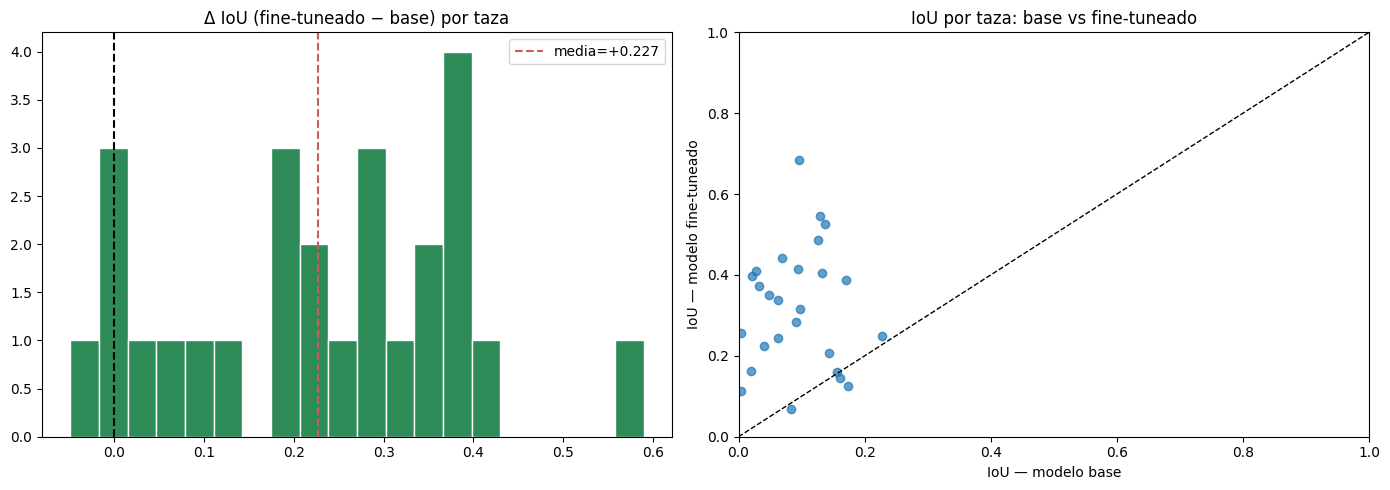

CONCLUSIÓN — FINE-TUNING SOBRE TAZAS ROTAS
IoU medio base:         0.0929
IoU medio fine-tuneado: 0.3200
Mejora media:           +0.2272

Tazas que mejoran: 23/26  |  empeoran: 3  |  igual: 0

Peores 5 casos (fine-tuneado):


,identificador,iou_base,iou_ft,mejora_iou
24,f3a7f8198cc50c225f5e789acd4d1122_ft1,0.082636,0.069170,-0.013466
1,141f1db25095b16dcfb3760e4293e310_ft1,0.004367,0.112613,0.108246
0,1038e4eac0e18dcce02ae6d2a21d494a_ft1,0.174163,0.125372,-0.048792
15,85d5e7be548357baee0fa456543b8166_ft1,0.160983,0.145799,-0.015184
11,5310945bb21d74a41fabf3cbd0fc77bc_ft1,0.155668,0.160469,0.004801



Mejores 5 casos (fine-tuneado):


,identificador,iou_base,iou_ft,mejora_iou
14,71995893d717598c9de7b195ccfa970_ft1,0.095898,0.685285,0.589387
10,46ed9dad0440c043d33646b0990bb4a_ft1,0.130049,0.544681,0.414632
9,44f9c4e1ea3532b8d7b20fded0142d7a_ft1,0.137491,0.525773,0.388282
8,3d3e993f7baa4d7ef1ff24a8b1564a36_ft1,0.126611,0.486824,0.360214
23,f1e439307b834015770a0ff1161fa15a_ft1,0.069050,0.442167,0.373117


In [26]:
# ============================================================
# 12. RESUMEN AGREGADO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_comparacion_objetos["mejora_iou"], bins=20, color="seagreen", edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--")
axes[0].axvline(df_comparacion_objetos["mejora_iou"].mean(), color="indianred", linestyle="--",
                label=f"media={df_comparacion_objetos['mejora_iou'].mean():+.3f}")
axes[0].set_title("Δ IoU (fine-tuneado − base) por taza"); axes[0].legend()

axes[1].scatter(df_comparacion_objetos["iou_base"], df_comparacion_objetos["iou_ft"], alpha=0.7)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_xlabel("IoU — modelo base"); axes[1].set_ylabel("IoU — modelo fine-tuneado")
axes[1].set_title("IoU por taza: base vs fine-tuneado"); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.tight_layout(); plt.show()

n_mejoran = (df_comparacion_objetos["mejora_iou"] > 0).sum()
n_empeoran = (df_comparacion_objetos["mejora_iou"] < 0).sum()
n_igual = (df_comparacion_objetos["mejora_iou"] == 0).sum()

print("=" * 75); print("CONCLUSIÓN — FINE-TUNING SOBRE TAZAS ROTAS"); print("=" * 75)
print(f"IoU medio base:         {df_comparacion_objetos['iou_base'].mean():.4f}")
print(f"IoU medio fine-tuneado: {df_comparacion_objetos['iou_ft'].mean():.4f}")
print(f"Mejora media:           {df_comparacion_objetos['mejora_iou'].mean():+.4f}")
print(f"\nTazas que mejoran: {n_mejoran}/{len(df_comparacion_objetos)}  |  "
      f"empeoran: {n_empeoran}  |  igual: {n_igual}")

print("\nPeores 5 casos (fine-tuneado):")
display(df_comparacion_objetos.nsmallest(5, "iou_ft")[["identificador", "iou_base", "iou_ft", "mejora_iou"]])
print("\nMejores 5 casos (fine-tuneado):")
display(df_comparacion_objetos.nlargest(5, "iou_ft")[["identificador", "iou_base", "iou_ft", "mejora_iou"]])